# Local Structure Optimisation with DFT

## Overview
**Questions**
- How do I find the minimum energy structure?
- How do I find the minimum energy lattice parameters?
- How do I optimise a defect geometry?

**Objectives**
- Use the BFGS optimiser to relax a structure
- Relax a structure and the unit cell
- Understand the importance of geometry relaxation for defect calculations

**Key Points**

- Geometry optimisation finds the minimum energy atomic configuration
- **BFGS** is the standard choice
- Convergence criterion (`fmax` in ASE) is the maximum force component (typically 0.01–0.05 eV/Å for DFT)
- Defect supercell relaxation is essential before computing electronic or optical properties


## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial2_MaterialsBasics.pptx) &nbsp;|&nbsp; [Open in full screen](https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={f1a4436d-dc16-46a0-bad5-435c95dc3d85}&amp;action=embedview&amp;wdAr=1.7777777777777777)

<iframe
  src="https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={f1a4436d-dc16-46a0-bad5-435c95dc3d85}&amp;action=embedview&amp;wdAr=1.7777777777777777"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

## Why Geometry Optimisation?

Before computing any electronic property, we must find the minimum energy geometry. 
In the context of quantum optics, the emission energy of a defect depends sensitively on the relaxed geometry of both ground and excited defect states.

### Example: optimising FCC Al

To begin with, let's import the libraries we need (including GPAW and ASE), and create a copper FCC structure. We rattle the atoms to take them a little out of equilibrium so that we can demonstrate geometric relaxation.

In [5]:
import numpy as np
import ase, gpaw
from ase.build import bulk
from gpaw import GPAW, PW

atoms = ase.build.bulk('Al','fcc',a=4.7)
atoms.rattle(0.01)

Second, we attach GPAW as a calculator.

We specify a number of parameters:
- `xc` sets the exchange-correlation functional
- `kpts` sets the Brillouin-zone sampling
- `mode` sets the basis set; in this case a 400 eV cutoff plane-wave basis is used.
- `output_log` set where the output will be printed to. If this is removed it will be printed in the notebook output.

For more information about valid parameters, see the [GPAW docs](https://wiki.fysik.dtu.dk/gpaw/documentation/basic.html#parameters).


In [16]:
atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="lcao", basis='dzp',txt='output_log.txt')

Timing:                              incl.     excl.
-----------------------------------------------------------
Forces:                              0.070     0.070   0.0% |
Hamiltonian:                         0.352     0.004   0.0% |
 Atomic:                             0.282     0.003   0.0% |
  XC Correction:                     0.279     0.279   0.0% |
 Calculate atomic Hamiltonians:      0.003     0.003   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.001     0.001   0.0% |
 XC 3D grid:                         0.062     0.062   0.0% |
LCAO initialization:                 4.447     0.465   0.0% |
 LCAO eigensolver:                   1.804     0.003   0.0% |
  Calculate projections:             0.003     0.003   0.0% |
  DenseAtomicCorrection:             0.009     0.009   0.0% |
  Distribute overlap matrix:         0.001     0.001   0.0% |
  Orbital Layouts: 

Finally, we run the calculations: these tell us what the energy and forces are acting on the materials before they are relaxed.

In [17]:
print(f"Initial energy: {atoms.get_potential_energy():.6f} eV")
print(f"Initial max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")

Initial energy: -6.407110 eV
Initial max force: 0.005702 eV/Å


Now we relax the atoms using the `BFGS` optimiser in ASE. The atoms will relax until the force acting on them is less than 0.001 eV/Å.

In [19]:
from ase.optimize import BFGS

opt = BFGS(atoms)
opt.run(fmax=0.01)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

      Step     Time          Energy          fmax
BFGS:    0 13:29:34       -6.453718        0.006634
Final energy: -6.407110 eV
Final max force: 0.005702 eV/Å
Final lattice constant: 2.8707 Å


The final lattice parameter has not changed because we have relaxed the atoms only. To relax the cell we need to attach a `unitcellfilter` to the `Atoms` object. `hydrostatic_strain` ensures that the cell shape is kept constant. Cell relaxations require a calculation of the stress tensor, and this is only implemented for plane-wave in `GPAW`. Therefore, we will attach a new plane-wave calculator.

This is a more intensive calculation and may take minutes to complete.

In [21]:
from ase.filters import UnitCellFilter
from ase.optimize import BFGS
from ase.io.trajectory import Trajectory

atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="pw",txt="pw_output_log.txt")

ucfilter = UnitCellFilter(atoms,hydrostatic_strain=True)
opt = BFGS(ucfilter)
opt.run(fmax=0.01)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

Timing:                              incl.     excl.
-----------------------------------------------------------
Forces:                              0.008     0.008   0.0% |
Hamiltonian:                         0.044     0.001   0.0% |
 Atomic:                             0.035     0.000   0.0% |
  XC Correction:                     0.034     0.034   0.0% |
 Calculate atomic Hamiltonians:      0.000     0.000   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.000     0.000   0.0% |
 XC 3D grid:                         0.008     0.008   0.0% |
LCAO initialization:                 0.604     0.060   0.0% |
 LCAO eigensolver:                   0.260     0.000   0.0% |
  Calculate projections:             0.000     0.000   0.0% |
  DenseAtomicCorrection:             0.001     0.001   0.0% |
  Distribute overlap matrix:         0.000     0.000   0.0% |
  Orbital Layouts: 

### Discussion

How does this compare to the Al lattice parameter calculated in last lab? Why might there be differences?

## Trajectories

A **trajectory** is a sequence of `Atoms` objects, typically snapshots from a molecular dynamics run or a geometry optimisation. ASE has a native `.traj` format for storing these efficiently. Let's run through the relaxation routine again, this time for Ti.

In [24]:
from ase.io.trajectory import Trajectory

atoms = ase.build.bulk('Ti','fcc',a=4.7)
atoms.rattle(0.1)

atoms.calc = GPAW(xc='PBE', kpts=(3, 3, 3), mode="pw",txt="Ti_output_log.txt")

print(f"Initial energy: {atoms.get_potential_energy():.6f} eV")
print(f"Initial max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Initial lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

ucfilter = UnitCellFilter(atoms,hydrostatic_strain=True)
opt = BFGS(ucfilter, trajectory='Ti_opt.traj', logfile='Ti_opt.log')
opt.run(fmax=0.001)

print(f"Final energy: {atoms.get_potential_energy():.6f} eV")
print(f"Final max force: {np.max(np.abs(atoms.get_forces())):.6f} eV/Å")
print(f"Final lattice constant: {atoms.cell.cellpar()[0]:.4f} Å")

Initial energy: -5.677267 eV
Initial max force: 0.000433 eV/Å
Initial lattice constant: 3.3234 Å
Timing:                              incl.     excl.
-----------------------------------------------------------
Forces:                              0.007     0.007   0.0% |
Hamiltonian:                         0.039     0.001   0.0% |
 Atomic:                             0.029     0.000   0.0% |
  XC Correction:                     0.029     0.029   0.0% |
 Calculate atomic Hamiltonians:      0.000     0.000   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.000     0.000   0.0% |
 XC 3D grid:                         0.009     0.009   0.0% |
LCAO initialization:                 0.179     0.012   0.0% |
 LCAO eigensolver:                   0.053     0.001   0.0% |
  Calculate projections:             0.001     0.001   0.0% |
  DenseAtomicCorrection:             0.001    

Now we can pull data from each step of the trajectory to track energy throughout the geometry optimisation.

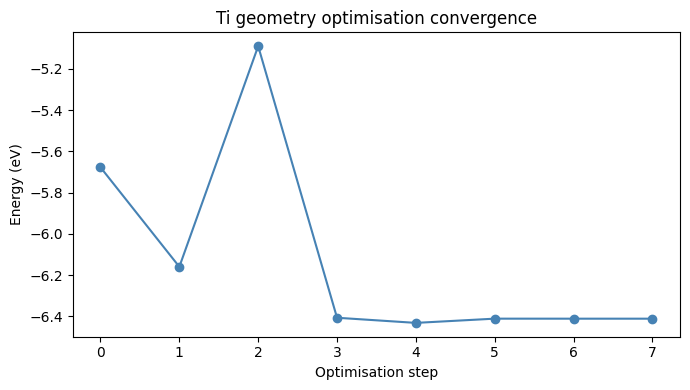

In [25]:
# Plot the energy convergence during optimisation
import matplotlib.pyplot as plt

traj = Trajectory('Ti_opt.traj')
energies = [atoms.get_potential_energy() for atoms in traj]
plt.figure(figsize=(7, 4))
plt.plot(energies, 'o-', color='steelblue')
plt.xlabel('Optimisation step')
plt.ylabel('Energy (eV)')
plt.title('Ti geometry optimisation convergence')
plt.tight_layout()
plt.show()


### Case Study: Just Relax

Find a material on the MaterialsProject and use DFT to relax it. This will be your personal "Case Study" material also used in future labs. Remember, the computational cost of DFT scales with $n**3$ (where $n$ is the number of atoms); so, you may want to find relatively simple materials (with one or two atoms in a unit cell).

## K-point convergence

DFT properties (e.g. total energy and forces) require integrating over the Brillouin zone; this is done numerically as a weighted sum over a discrete k-point mesh. k-point density scales inversely with cell size: a primitive cell needs a finer grid than a supercell
For a large defect supercell, a single Γ-point (k = 0,0,0) is often sufficient. More k-points are always more accurate, but also more expensive.

Note that for any calculation meshes must be converged. An example k-point convergence: we run the same calculation for increasing amounts of k-points, and look for where there is convergence below a particular energy criterion (for example, 1meV/atom).


Timing:                              incl.     excl.
-----------------------------------------------------------
Hamiltonian:                         0.035     0.000   0.0% |
 Atomic:                             0.026     0.000   0.0% |
  XC Correction:                     0.026     0.026   0.0% |
 Calculate atomic Hamiltonians:      0.000     0.000   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.000     0.000   0.0% |
 XC 3D grid:                         0.008     0.008   0.0% |
LCAO initialization:                 0.290     0.013   0.0% |
 LCAO eigensolver:                   0.050     0.001   0.0% |
  Calculate projections:             0.001     0.001   0.0% |
  DenseAtomicCorrection:             0.003     0.003   0.0% |
  Distribute overlap matrix:         0.000     0.000   0.0% |
  Orbital Layouts:                   0.004     0.004   0.0% |
  Potential matrix:

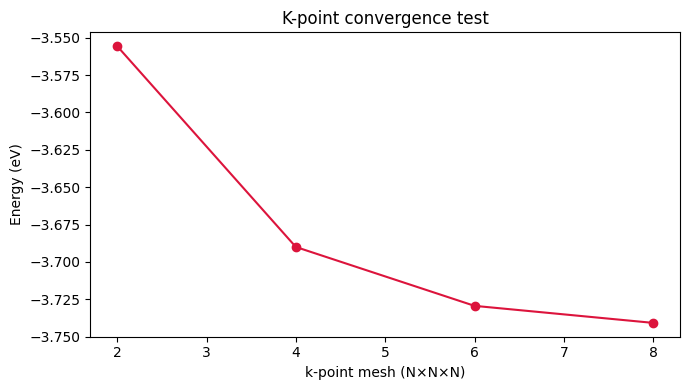

In [26]:
al = bulk('Al', 'fcc', a=4.05)
k_values = [2, 4, 6, 8]
energies_k = []

for k in k_values:
    al.calc = GPAW(xc='PBE', kpts=(k, k, k), mode="pw",txt="k_point-log.txt")
    energies_k.append(al.get_potential_energy())

plt.figure(figsize=(7, 4))
plt.plot(k_values, energies_k, 'o-', color='crimson')
plt.xlabel('k-point mesh (N×N×N)')
plt.ylabel('Energy (eV)')
plt.title('K-point convergence test')
plt.tight_layout()
plt.show()

### Exercise: k-point convergence

i) Take your material from the `Just Relax` exercise and perform a k-point convergence until the energy is converged to at least 5meV/atom;  
ii) Now build a 2x2x2 supercell of the material and conduct the same k-point convergence.

Do the k-points converge more quickly or less quickly for the supercell? Why is there a difference between the primitive cell and the supercell?

### Exercise: defect relaxation

Build a 2×2×2 supercell of wurtzite GaN and introduce a nitrogen vacancy (V_N) by deleting one N atom. Relax the structure with BFGS using DFT. By how much does the nearest Ga atom move inward toward the vacancy? (This "breathing mode" relaxation is a characteristic signature of point defects.)